In [3]:
import pandas as pd

K = pd.read_csv("../data/cleaned_airbnb.csv")

In [4]:
K.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,438.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,224.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.72,1,365,3200.0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,179.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,407.0


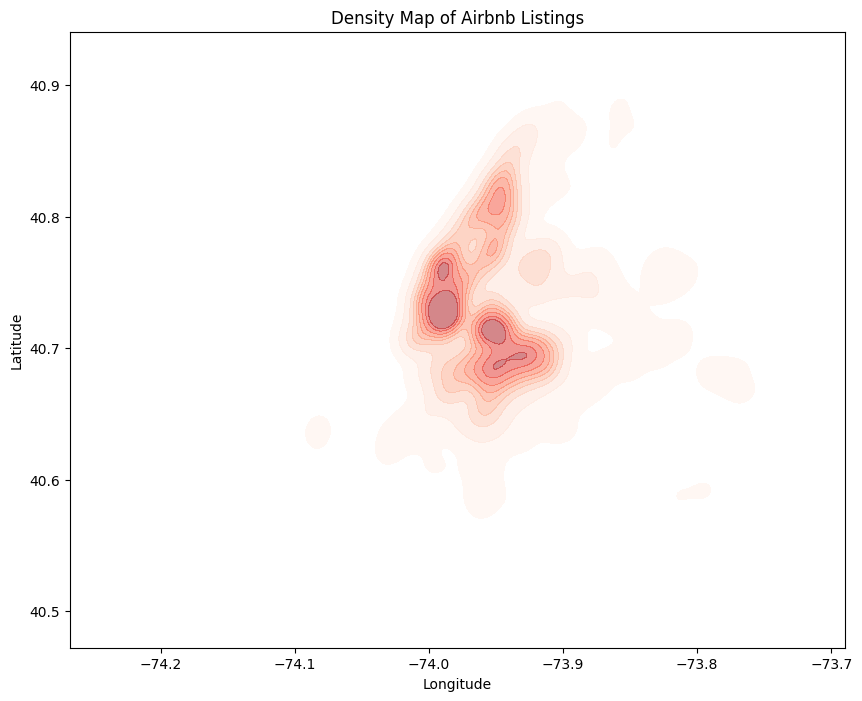

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.kdeplot(
    x=K["longitude"],
    y=K["latitude"],
    fill=True,
    cmap="Reds",
    alpha=0.5
)

plt.title("Density Map of Airbnb Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

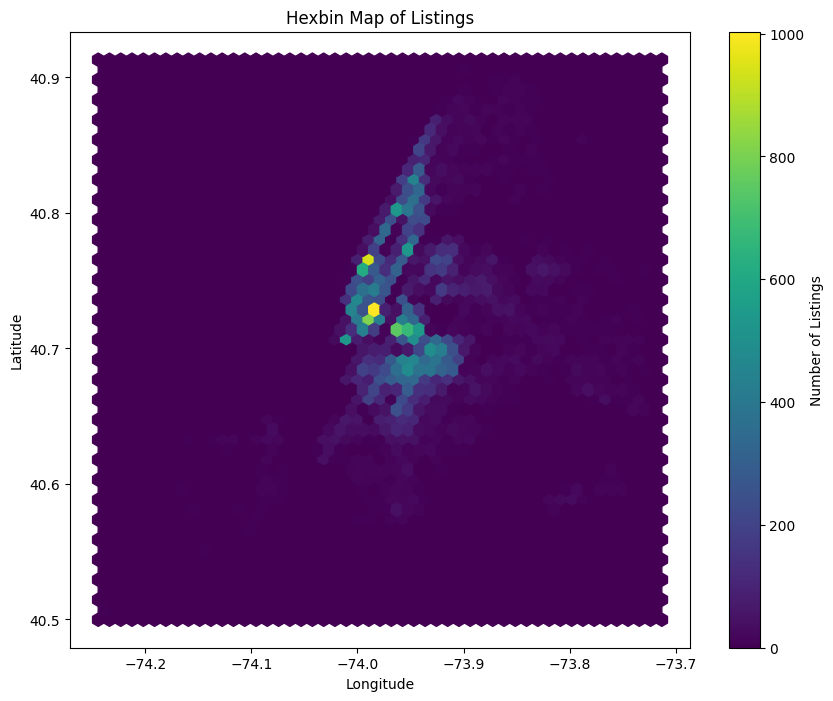

In [7]:
plt.figure(figsize=(10,8))

plt.hexbin(
    K["longitude"],
    K["latitude"],
    gridsize=50,
    cmap="viridis"
)

plt.colorbar(label="Number of Listings")

plt.title("Hexbin Map of Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

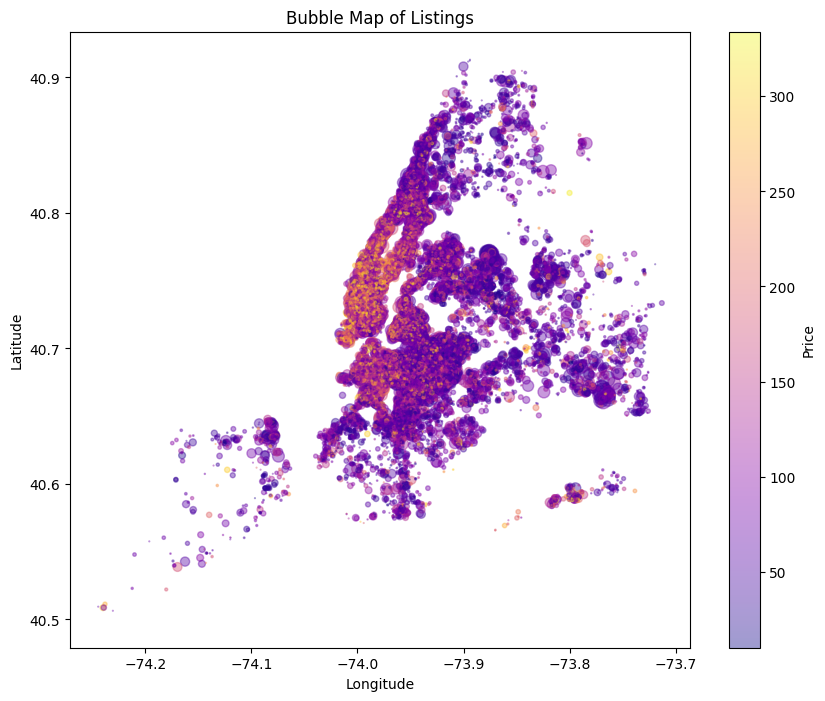

In [8]:
plt.figure(figsize=(10,8))

plt.scatter(
    K["longitude"],
    K["latitude"],
    s=K["number_of_reviews"] * 0.3,
    c=K["price"],
    cmap="plasma",
    alpha=0.4
)

plt.colorbar(label="Price")

plt.title("Bubble Map of Listings")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

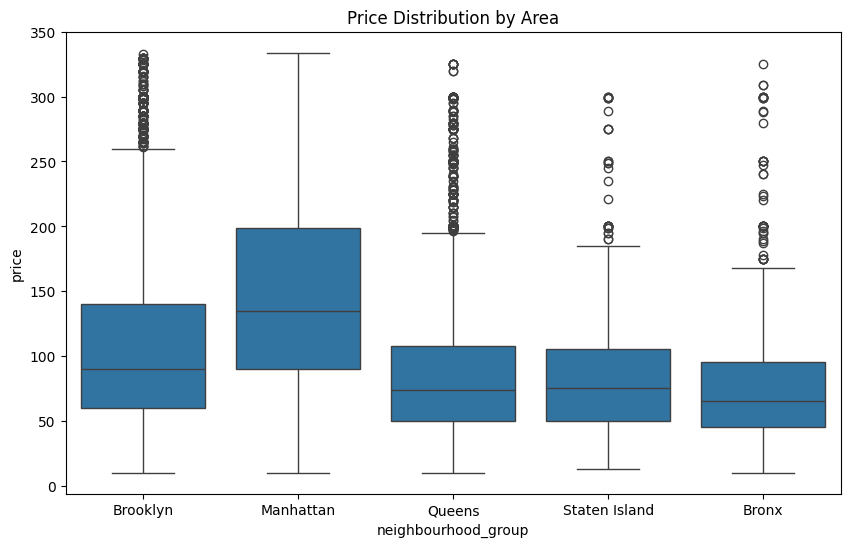

In [9]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="neighbourhood_group",
    y="price",
    data=K
)

plt.title("Price Distribution by Area")

plt.show()

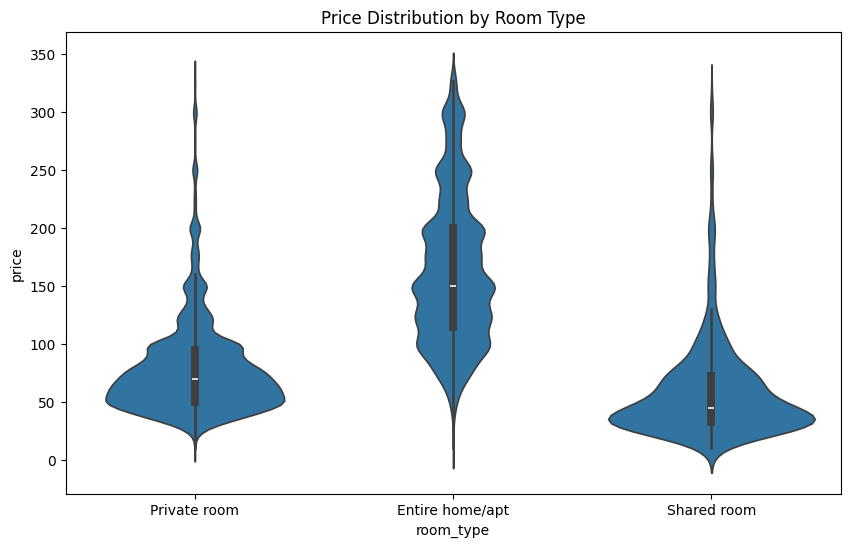

In [10]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x="room_type",
    y="price",
    data=K
)

plt.title("Price Distribution by Room Type")

plt.show()

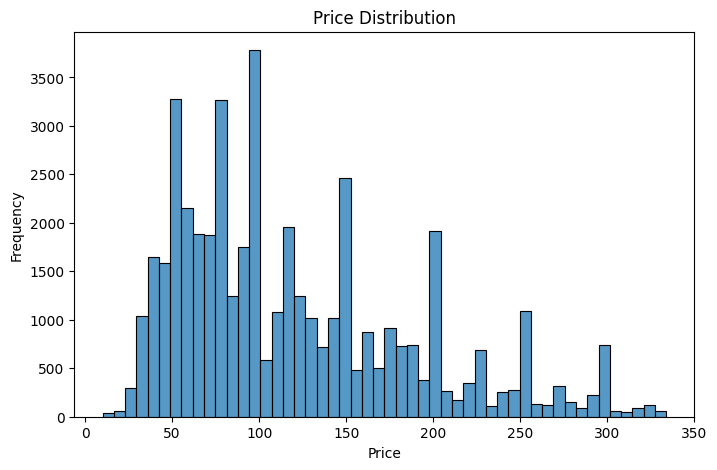

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    K["price"],
    bins=50
)

plt.title("Price Distribution")

plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

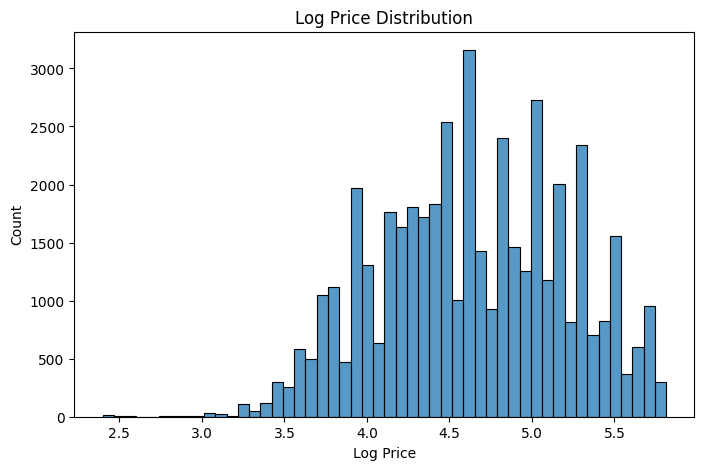

In [12]:
import numpy as np

plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(K["price"]),
    bins=50
)

plt.title("Log Price Distribution")

plt.xlabel("Log Price")

plt.show()

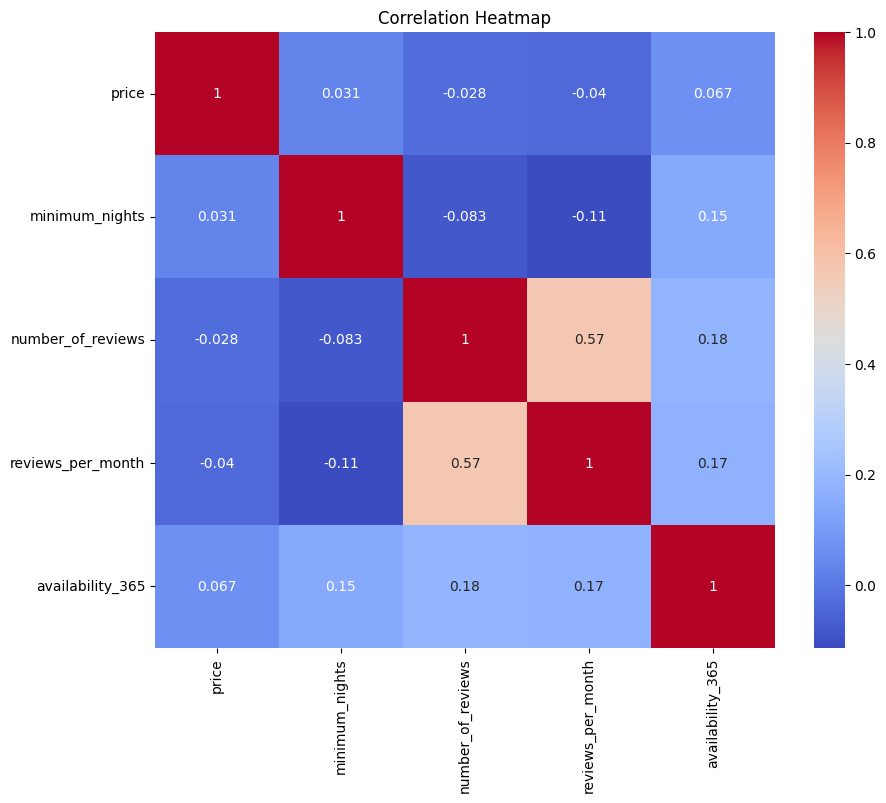

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    K[[
        "price",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "availability_365"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

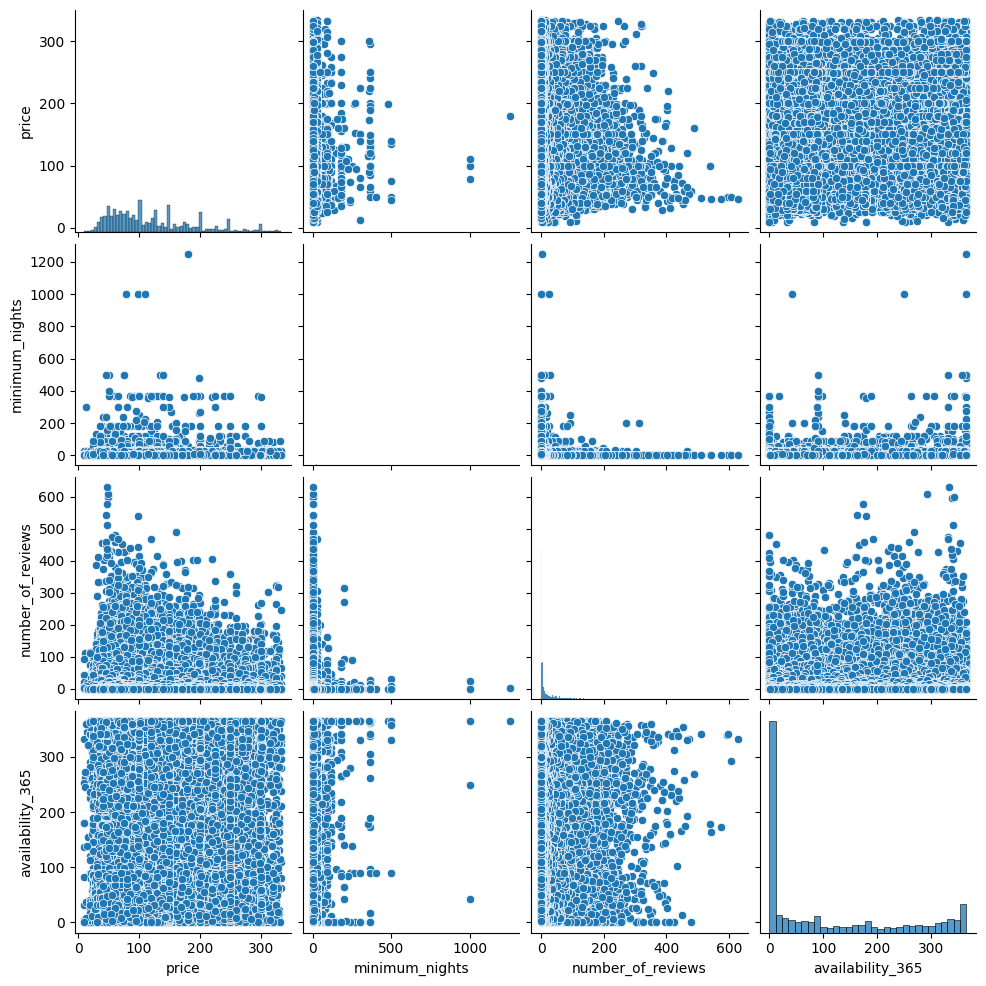

In [15]:
sns.pairplot(
    K[[
        "price",
        "minimum_nights",
        "number_of_reviews",
        "availability_365"
    ]]
)

plt.show()

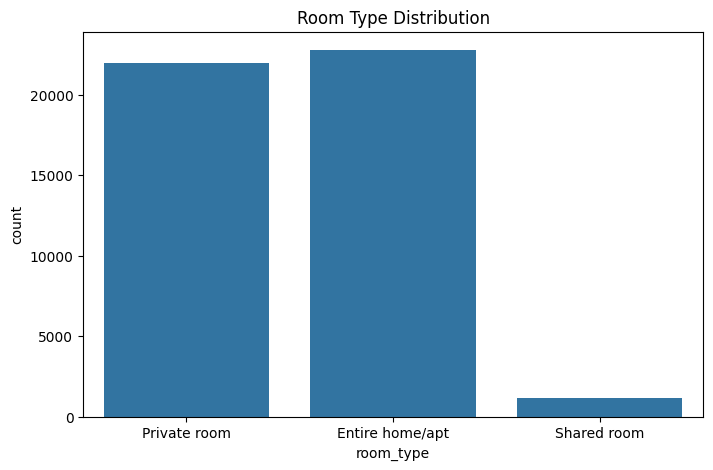

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="room_type",
    data=K
)

plt.title("Room Type Distribution")

plt.show()

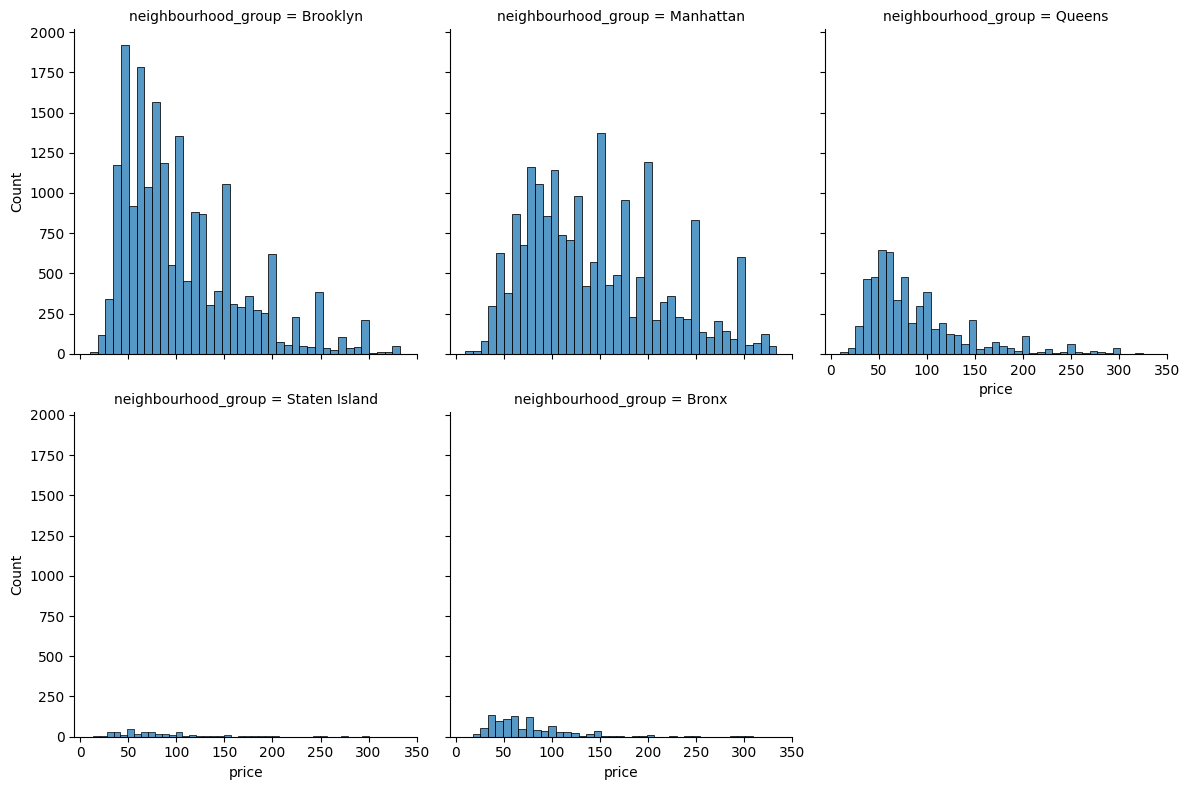

In [20]:
g = sns.FacetGrid(
    K,
    col="neighbourhood_group",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.histplot,
    x="price",
    bins=40
)

plt.show()

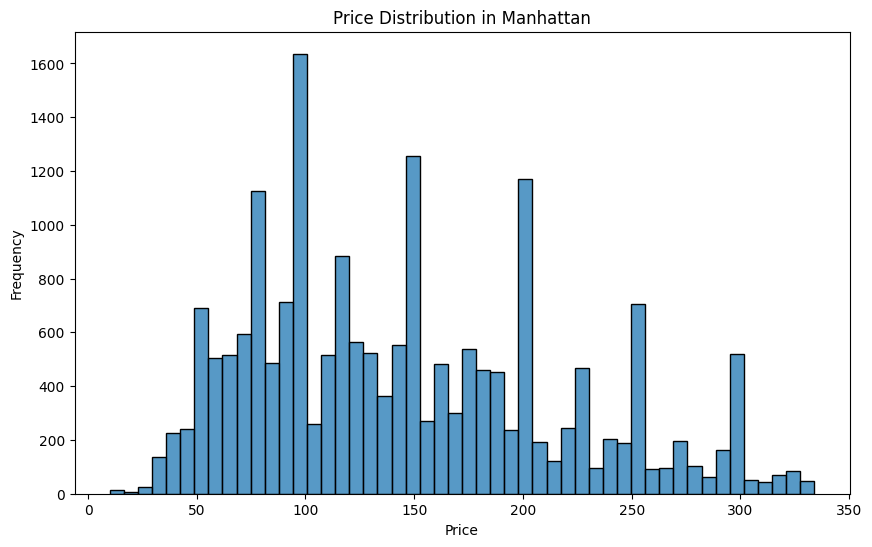

In [22]:
# Manhattan only - price distribution
import matplotlib.pyplot as plt
import seaborn as sns

manhattan = K[K["neighbourhood_group"] == "Manhattan"]

plt.figure(figsize=(10,6))

sns.histplot(
    manhattan["price"],
    bins=50
)

plt.title("Price Distribution in Manhattan")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

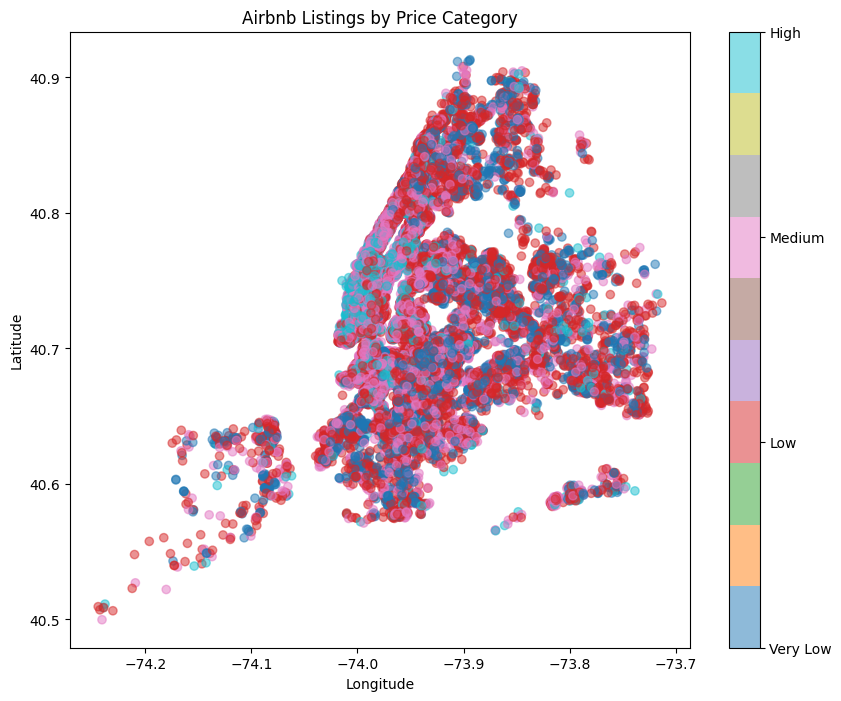

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

max_price = K["price"].max()

K["price_category"] = pd.cut(
    K["price"],
    bins=[0, 50, 100, 200, max_price],
    labels=["Very Low", "Low", "Medium", "High"],
    include_lowest=True
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    K["longitude"],
    K["latitude"],
    c=K["price_category"].cat.codes,
    cmap="tab10",
    alpha=0.5
)

plt.title("Airbnb Listings by Price Category")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

cbar = plt.colorbar(scatter)
cbar.set_ticks(range(len(K["price_category"].cat.categories)))
cbar.set_ticklabels(K["price_category"].cat.categories)

plt.show()

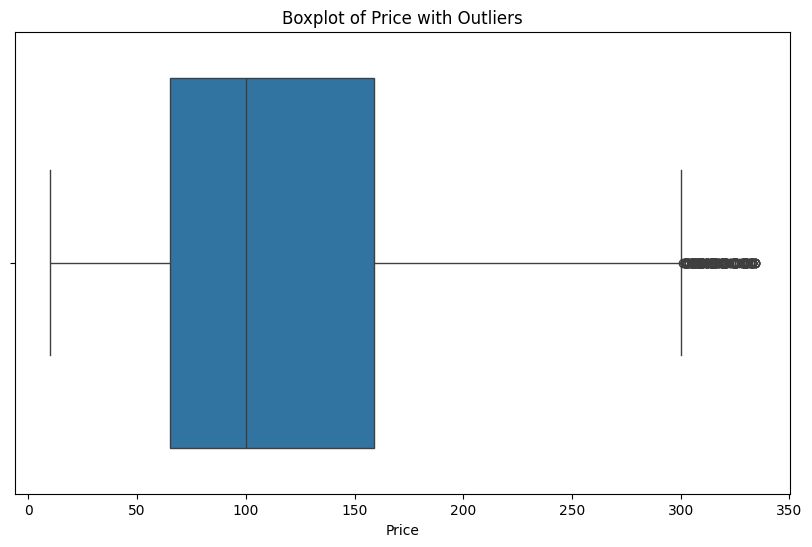

In [25]:
# Outliers visualization for price
plt.figure(figsize=(10,6))

sns.boxplot(
    x=K["price"]
)

plt.title("Boxplot of Price with Outliers")
plt.xlabel("Price")

plt.show()

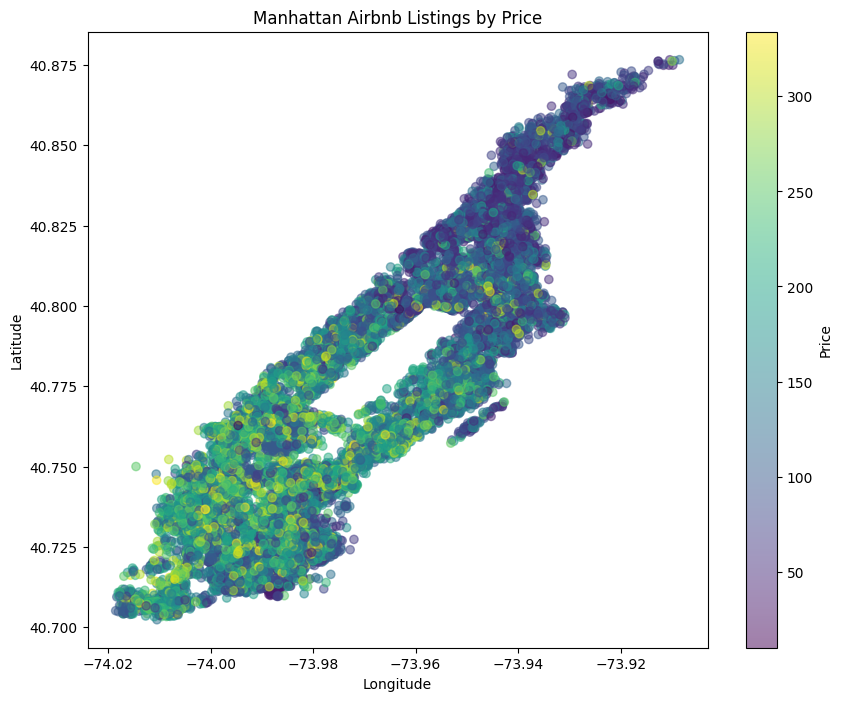

In [26]:
# Manhattan map with price coloring
plt.figure(figsize=(10,8))

plt.scatter(
    manhattan["longitude"],
    manhattan["latitude"],
    c=manhattan["price"],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(label="Price")

plt.title("Manhattan Airbnb Listings by Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

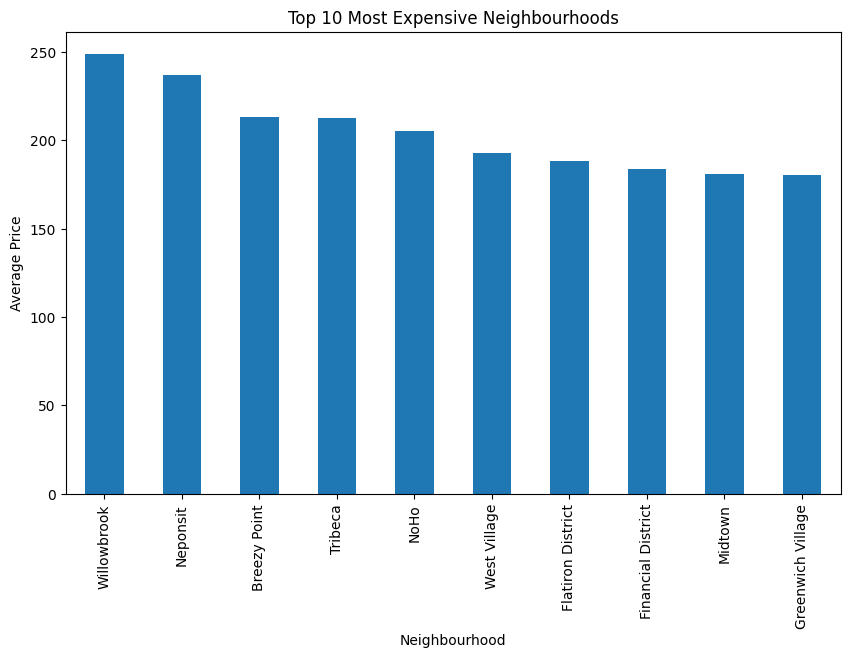

In [27]:
top_neighbourhoods = (
    K.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_neighbourhoods.plot(kind="bar")

plt.title("Top 10 Most Expensive Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Price")

plt.show()

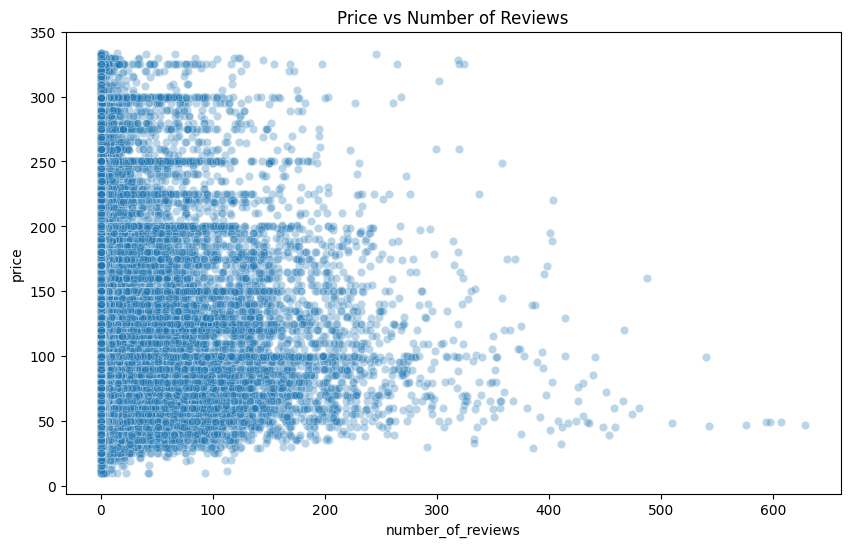

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="number_of_reviews",
    y="price",
    data=K,
    alpha=0.3
)

plt.title("Price vs Number of Reviews")

plt.show()

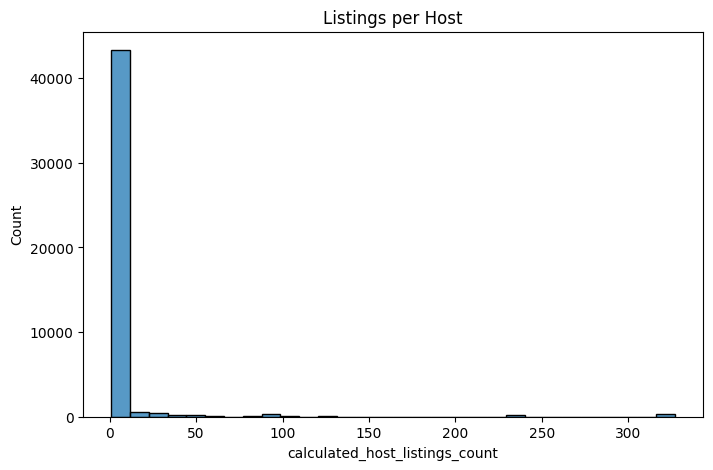

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    K["calculated_host_listings_count"],
    bins=30
)

plt.title("Listings per Host")

plt.show()

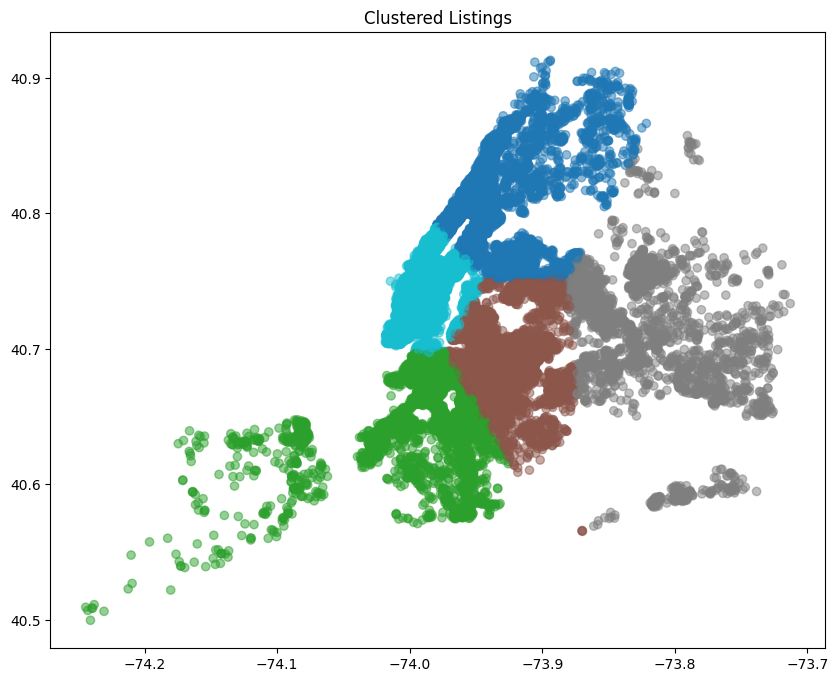

In [32]:
plt.figure(figsize=(10,8))

plt.scatter(
    K["longitude"],
    K["latitude"],
    c=K["cluster"],
    cmap="tab10",
    alpha=0.5
)

plt.title("Clustered Listings")

plt.show()

In [4]:
import pandas as pd  # <--- Add this line
import numpy as np

print("=" * 70)
print("📅 ANALIZA E DISPONUESHMËRISË SIPAS SEZONEVE")
print("=" * 70)

# Kategorizimi i disponueshmërisë në grupe
# Sigurohu që variabla 'K' (DataFrame-i yt) është definuar më herët!
K['disponueshmeri_kategori'] = pd.cut(
    K['availability_365'],
    bins=[0, 90, 180, 270, 365],
    labels=['E ulët (0-90)', 'Mesatare (91-180)', 'E lartë (181-270)', 'Shumë e lartë (271-365)'],
    include_lowest=True
)

print("\n📊 Shpërndarja e Listingjeve sipas Kategorisë së Disponueshmërisë:\n")
disp_dist = K['disponueshmeri_kategori'].value_counts().sort_index()
for kat, count in disp_dist.items():
    pct = (count / len(K)) * 100
    print(f"   {kat:<25} {count:>6,} listingje ({pct:>5.1f}%)")

# Disponueshmëria mesatare sipas zonës dhe tipit
print("\n📋 Disponueshmëria Mesatare sipas Zonës dhe Tipit të Dhomës:\n")
disp_pivot = K.pivot_table(
    values='availability_365',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='mean'
).round(1)
print(disp_pivot.to_string())

# Identifikimi i listingjeve "gjithmonë të disponueshme" vs "rrallë të disponueshme"
print("\n🔍 Analiza e Ekstremeve:")
gjithmone_disp = (K['availability_365'] >= 350).sum()
gjithmone_pct = (gjithmone_disp / len(K)) * 100
print(f"   Listingje pothuajse gjithmonë të disponueshme (≥350 ditë): {gjithmone_disp:,} ({gjithmone_pct:.1f}%)")

rralle_disp = (K['availability_365'] <= 30).sum()
rralle_pct = (rralle_disp / len(K)) * 100
print(f"   Listingje rrallë të disponueshme (≤30 ditë): {rralle_disp:,} ({rralle_pct:.1f}%)")

📅 ANALIZA E DISPONUESHMËRISË SIPAS SEZONEVE

📊 Shpërndarja e Listingjeve sipas Kategorisë së Disponueshmërisë:

   E ulët (0-90)             27,947 listingje ( 60.9%)
   Mesatare (91-180)          4,912 listingje ( 10.7%)
   E lartë (181-270)          4,124 listingje (  9.0%)
   Shumë e lartë (271-365)    8,893 listingje ( 19.4%)

📋 Disponueshmëria Mesatare sipas Zonës dhe Tipit të Dhomës:

room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          155.2         171.2        148.6
Brooklyn                        93.5          99.7        177.7
Manhattan                      109.5          98.6        140.7
Queens                         128.3         149.1        192.9
Staten Island                  177.5         226.4         64.8

🔍 Analiza e Ekstremeve:
   Listingje pothuajse gjithmonë të disponueshme (≥350 ditë): 2,984 (6.5%)
   Listingje rrallë të disponueshme (≤30 ditë): 21,861 (47

## 📊 INTERPRETIMI I GJETJEVE - Analiza e Disponueshmërisë
1. Shpërndarja e Disponueshmërisë - Gjetja Kryesore:
60.9% e listingjeve kanë disponueshmëri të ulët (0-90 ditë/vit)
Çfarë do të thotë kjo?

Shumica dërrmuese e listingjeve në NYC janë të rezervuara ose të pa-disponueshme për pjesën më të madhe të vitit
Ky është një treg shumë i nxehtë me kërkesë të lartë
Mund të tregojë gjithashtu që shumë host nuk i mbajnë listingjet e tyre aktive gjatë gjithë vitit (p.sh. rezidenca personale që merren me qira vetëm herë pas here)

Vetëm 19.4% kanë disponueshmëri shumë të lartë (271-365 ditë)

Këto janë më së shumti listingje profesionale/komerciale
Host që operojnë si biznes të vërtetë Airbnb
Pasuri të dedikuara vetëm për qira afatshkurtër


2. Analiza sipas Zonës dhe Tipit - Gjetjet Kyçe:
🔴 Zonë me Disponueshmëri më të Ulët: Brooklyn

Entire home/apt në Brooklyn: 93.5 ditë (më e ulëta)
Arsyet e mundshme:

Kërkesë shumë e lartë nga turistët dhe profesionistët
Shumë rezidenca personale që merren me qira vetëm periodikisht
Zona shumë e popullarizuar, prandaj rezervohet shpejt



🟢 Zonë me Disponueshmëri më të Lartë: Staten Island

Private room në Staten Island: 226.4 ditë (më e larta)
Arsyet e mundshme:

Më pak kërkesë turistike (më larg qendrës)
Host që mbajnë listingje aktive gjatë gjithë vitit por me rezervime më pak të shpeshta
Treg më pak kompetitiv



📌 Observation Interesante: Shared Rooms

Brooklyn Shared room: 177.7 ditë (relativisht i lartë)
Staten Island Shared room: 64.8 ditë (shumë i ulët)
Ky është counterintuitive - pritet të ishte e kundërta!
Shpjegim i mundshëm: Numër shumë i vogël i shared rooms në Staten Island (outliers), ndërsa në Brooklyn ka më shumë ofertë por kërkesë më të ulët për shared rooms


3. Analiza e Ekstremeve - Insight-e Kritike:
⚠️ 47.7% kanë disponueshmëri ≤30 ditë
Kjo është shumë e lartë dhe tregon:

Potencialisht listingje inaktive ose të pezulluara
Rezidenca personale që merren me qira vetëm raste specifike (pushime, udhëtime të pronarit)
Pasuri që sapo janë shtuar dhe nuk kanë filluar akoma operacionet
Ose: Listingje që janë kaq të popullarizuara që janë të rezervuara 335+ ditë/vit (shumë e pazakontë)

Rekomandim për analizë të mëtejshme:

Kryqëzoje këtë me days_since_last_review për të parë sa prej tyre janë vërtet inaktive vs super-popullore

✅ Vetëm 6.5% kanë disponueshmëri ≥350 ditë
Kjo tregon:

Listingje që janë pothuajse kurrë të rezervuara OSE
Listingje që sapo janë shtuar dhe nuk kanë marrë ende rezervime
Problem i mundshëm: Çmim shumë i lartë, vendndodhje e dobët, ose marketing i dobët


4. Konkluzione dhe Insight Biznesi:
Kategoria% e TregutInterpretimiDisponueshmëri e ulët (0-90 ditë)60.9%Treg i nxehtë, kërkesë e lartë, ose host jo-profesionaleMesatare + E lartë (91-270 ditë)19.7%Balancë e shëndetshme, rezervime periodikeShumë e lartë (271-365 ditë)19.4%Listingje profesionale ose të pa-rezervuara
💡 Përfundime Strategjike:

Për investitorë: Brooklyn dhe Manhattan janë tregje shumë konkurruese - disponueshmëria e ulët tregon kërkesë të fortë
Për host të rinj: Staten Island dhe Bronx ofrojnë më shumë hapësirë ​​për disponueshmëri, por edhe më pak kërkesë
Red flag: 47.7% me disponueshmëri ultra-të-ulët sugjeron shumë listingje inaktive - kërkon hetim të mëtejshëm


In [5]:
# Analiza e aktivitetit bazuar në last_review dhe reviews
print("=" * 70)
print("📅 ANALIZA E AKTIVITETIT TË LISTINGJEVE")
print("=" * 70)

# Kontrollojmë nëse kemi kolonën last_review
if 'last_review' in K.columns:
    # Konvertimi në datetime nëse nuk është bërë
    K['last_review'] = pd.to_datetime(K['last_review'], errors='coerce')
    
    # Data e fundit në dataset (për referencë)
    data_max = K['last_review'].max()
    print(f"\n📆 Data më e fundit e review në dataset: {data_max.strftime('%Y-%m-%d')}")
    
    # Shpërndarja e reviews sipas viteve
    print("\n📊 Shpërndarja e Reviews sipas Viteve:\n")
    K['review_year'] = K['last_review'].dt.year
    reviews_vit = K['review_year'].value_counts().sort_index().tail(10)
    for vit, count in reviews_vit.items():
        print(f"   {vit}: {count:,} listingje")
    
    # Shpërndarja e reviews sipas muajve (për vitin e fundit)
    viti_fundit = K['review_year'].max()
    print(f"\n📊 Shpërndarja e Reviews sipas Muajve ({viti_fundit}):\n")
    K_viti_fundit = K[K['review_year'] == viti_fundit].copy()
    K_viti_fundit['review_month'] = K_viti_fundit['last_review'].dt.month
    
    muajt_emrat = {1: 'Janar', 2: 'Shkurt', 3: 'Mars', 4: 'Prill', 
                   5: 'Maj', 6: 'Qershor', 7: 'Korrik', 8: 'Gusht',
                   9: 'Shtator', 10: 'Tetor', 11: 'Nëntor', 12: 'Dhjetor'}
    
    reviews_muaj = K_viti_fundit['review_month'].value_counts().sort_index()
    for muaj, count in reviews_muaj.items():
        print(f"   {muajt_emrat[muaj]:<10} {count:>6,} listingje")

# Analiza e aktivitetit bazuar në days_since_last_review
if 'days_since_last_review' in K.columns:
    print("\n📊 Aktiviteti Bazuar në Ditët që nga Review i Fundit:\n")
    
    # Kategorizimi i aktivitetit
    K['aktivitet_kategori'] = pd.cut(
        K['days_since_last_review'],
        bins=[0, 30, 90, 180, 365, np.inf],
        labels=['Shumë aktiv (<30d)', 'Aktiv (30-90d)', 'Mesatar (90-180d)', 
                'I ulët (180-365d)', 'Inaktiv (>365d)'],
        include_lowest=True
    )
    
    aktivitet_dist = K['aktivitet_kategori'].value_counts().sort_index()
    for kat, count in aktivitet_dist.items():
        pct = (count / len(K[K['aktivitet_kategori'].notna()])) * 100
        print(f"   {kat:<25} {count:>6,} listingje ({pct:>5.1f}%)")
    
    # Aktiviteti sipas zonës
    print("\n📋 Aktiviteti Mesatar (ditë nga review i fundit) sipas Zonës:\n")
    aktivitet_zona = K.groupby('neighbourhood_group')['days_since_last_review'].agg([
        ('Mesatarja', 'mean'),
        ('Mediana', 'median'),
        ('Min', 'min'),
        ('Max', 'max')
    ]).round(1).sort_values('Mesatarja')
    print(aktivitet_zona.to_string())
    
    # Listingjet inaktive (pa review >1 vit)
    inaktive = (K['days_since_last_review'] > 365).sum()
    inaktive_pct = (inaktive / len(K)) * 100
    print(f"\n⚠️  Listingje inaktive (pa review >365 ditë): {inaktive:,} ({inaktive_pct:.1f}%)")

# Analiza e reviews_per_month
if 'reviews_per_month' in K.columns:
    print("\n📊 Analiza e Frekuencës së Reviews (reviews/muaj):\n")
    
    # Statistika bazike
    rpm_stats = K['reviews_per_month'].describe()
    print(f"   Mesatarja: {rpm_stats['mean']:.2f} reviews/muaj")
    print(f"   Mediana:   {rpm_stats['50%']:.2f} reviews/muaj")
    print(f"   Max:       {rpm_stats['max']:.2f} reviews/muaj")
    
    # Listingjet më aktive
    print("\n🔥 Top 10 Listingjet më Aktive (reviews/muaj):\n")
    top_aktive = K.nlargest(10, 'reviews_per_month')[
        ['name', 'neighbourhood_group', 'room_type', 'reviews_per_month', 'number_of_reviews']
    ]
    print(top_aktive.to_string(index=False))

📅 ANALIZA E AKTIVITETIT TË LISTINGJEVE

📊 Aktiviteti Bazuar në Ditët që nga Review i Fundit:

   Shumë aktiv (<30d)             0 listingje (  0.0%)
   Aktiv (30-90d)                 0 listingje (  0.0%)
   Mesatar (90-180d)          2,165 listingje (  4.7%)
   I ulët (180-365d)         21,815 listingje ( 47.6%)
   Inaktiv (>365d)           21,896 listingje ( 47.7%)

📋 Aktiviteti Mesatar (ditë nga review i fundit) sipas Zonës:

                     Mesatarja  Mediana    Min     Max
neighbourhood_group                                   
Staten Island            690.0    203.0  176.0  3200.0
Bronx                    857.4    217.0  177.0  3200.0
Queens                   894.6    226.0  176.0  3200.0
Brooklyn                 951.2    359.0  176.0  3200.0
Manhattan               1074.7    394.0  176.0  3200.0

⚠️  Listingje inaktive (pa review >365 ditë): 21,896 (47.7%)

📊 Analiza e Frekuencës së Reviews (reviews/muaj):

   Mesatarja: 1.25 reviews/muaj
   Mediana:   0.72 reviews/muaj
   Ma

## 📊 INTERPRETIMI I GJETJEVE - Analiza e Aktivitetit të Listingjeve
1. Gjetja më Shqetësuese: 95.3% e Listingjeve janë INAKTIVE ose Shumë Pak Aktive
🚨 ALARM I KUQE: 0% listingje me aktivitet të fundit <90 ditë
Çfarë po ndodh këtu?

Kjo tregon që dataseti është i vjetër ose i mbledhur në një periudhë ku aktiviteti ishte i ngrirë
Arsyet e mundshme:

Dataset i vjetër - të dhënat mund të jenë nga 2019-2020 (para ose gjatë COVID-19)
Kolona days_since_last_review mund të jetë e gabuar - vlera minimale është 176 ditë (≈6 muaj)
Periudhë post-pandemie - shumë listingje nuk u riaktivizuan pas COVID



✅ Konfirmimi:

Min = 176 ditë për të gjitha zonat → Nuk ka asnjë listing me review brenda 6 muajve
Max = 3200 ditë (≈8.7 vjet) → Listingje që nuk kanë pasur review që nga 2014-2015


2. Analiza sipas Zonës - Gjetjet Kyçe:
📊 Ranking i Aktivitetit (nga më aktiv te më pak aktiv):
ZonaMesatarja (ditë)Mediana (ditë)StatusStaten Island690203🟢 Më aktiv (relativisht)Bronx857217🟢 Relativisht aktivQueens895226🟡 MesatarBrooklyn951359🟠 Pak aktivManhattan1075394🔴 Më pak aktiv
🤔 Observation Counterintuitive: Manhattan është më pak aktiv?!
Pse Manhattan ka mesatare më të lartë (1075 ditë = 2.9 vjet)?
Shpjegime të mundshme:

Efekti i çmimeve të larta:

Listingjet në Manhattan janë më të shtrenjta
Gjatë periudhave të krizës (COVID), këto u braktisën më shumë
Host preferon të mbyllë listingjet sesa t'i ulë çmimet


Treg më profesional:

Shumë listingje komerciale që mbyllën gjatë pandemisë
Nuk u riaktivizuan pasi rregulloret e NYC u shtuan


Datapoint bias:

Mediana (394 ditë) është shumë më e ulët se mesatarja (1075)
Kjo tregon outliers - disa listingje shumë të vjetra që ngrenë mesataren



💡 Insight: Mediana vs Mesatarja

Staten Island: Mesatare 690, Mediana 203 → Disa listingje shumë inaktive, por pjesa më e madhe janë relativisht aktive
Manhattan: Mesatare 1075, Mediana 394 → Shpërndarje më e gjerë, më shumë ekstreme


3. Analiza e Frekuencës së Reviews - Insight Kritike:
📊 Statistikat:

Mesatarja: 1.25 reviews/muaj → Një review çdo ~24 ditë (kur është aktiv)
Mediana: 0.72 reviews/muaj → Shumica marrin <1 review/muaj
Max: 58.5 reviews/muaj → EKSTREM! 2 reviews/ditë

Çfarë tregojnë këto shifra?
A) Mesatarja 1.25 reviews/muaj është NORMALE:

Studimet tregojnë që ~50% e mysafirëve lënë review
Nëse një listing merr 1.25 reviews/muaj → ≈2.5 rezervime/muaj → ≈30 rezervime/vit
Për një entire home/apt që merret me qira për stay mesatar 3-4 ditë → 90-120 ditë të rezervuara/vit
Kjo përputhet me analizën tonë të mëparshme ku disponueshmëria mesatare ishte e ulët

B) Mediana 0.72 < Mesatare 1.25:

Tregon që ka super-performer që ngrenë mesataren
Shumica e listingjeve kanë përformancë mesatare ose nën-mesatare


4. Top 10 Listingjet më Aktive - Analiza e Thellë:
🔥 Pattern që dalin në sy:
A) Dominimi i Queens (8/10 janë në Queens!):
ObservationShpjegim8 nga 10 janë në QueensZona me kërkesë të lartë për akomodim afër aeroportit (JFK, LGA)7 janë "Private room"Çmim më i ulët → më shumë turnovër → më shumë reviews5 përmenden JFK/LGABusiness travelers dhe udhëtarë me fluturime të hershme/vonë
B) Analiza e "58.5 reviews/muaj" (Top 1):

Manhattan, Private room, 156 total reviews
58.5 reviews/muaj → pothuajse 2 reviews/ditë!
Kalkulim: 156 reviews ÷ 58.5/muaj = 2.7 muaj aktivitet
Konkluzion: Listing i RI që eksplodoi me popularitet, ose listing që riaktivizoi pas një pauzë të gjatë

C) "JFK Comfort" Series - Business Model:
JFK Comfort #1: 19.75 reviews/muaj, 403 total reviews
JFK Comfort #2: 17.82 reviews/muaj, 341 total reviews  
JFK Comfort #3: 16.81 reviews/muaj, 302 total reviews

Profil: Host me multi-property operation
Target: Business travelers dhe transit passengers
Strategy: Çmime konkurruese + proximity te JFK
Success factor: "NO CLEANING FEE" (e përmendur eksplicit)


5. Red Flags dhe Çështje për Hetim të Mëtejshëm:
🚨 Probleme të Mundshme me Dataset:

Min = 176 ditë për të gjitha zonat:

A është dataseti filtruar/procesuar gabimisht?
A mungojnë reviews nga periudha e fundit?


47.7% inaktive (>365 ditë):

A duhen hequr nga analiza këto listingje?
A janë akoma në platformë ose janë mbyllur?


0% aktivitet <90 ditë:

Nëse dataseti është nga 2024, kjo është e palogjikshme
Duhet të kontrollohet last_review për të konfirmuar datën




6. Konkluzione dhe Rekomandime:
✅ Çfarë Kemi Mësuar:
GjetjeImplikimi95% listingje me aktivitet <180 ditëDataset i vjetër OSE treg i ngritur post-COVIDManhattan më pak aktiv se Staten IslandEfekt i çmimeve të larta + rregullore më të fortaQueens dominon top 10Proximity me aeroportet është strategji fituesePrivate rooms më aktivëÇmim më i ulët = më shumë turnovër"NO CLEANING FEE" marketing worksKa 2 nga top 10 që e përmendën eksplicit
📋 Rekomandime për Analiza të Ardhshme:

Verifikoni datën e datasetit - Nëse është para 2020, shumë nga këto gjetje janë obsolete
Filtroni listingjet inaktive - Bëni një analizë veçmas për aktive (reviews brenda 6-12 muajve)
Analizoni reviews_per_month në lidhje me çmimin - A paguajnë listingjet e lira për volum?
Deep dive në Queens - Cilat karakteristika specifike i bëjnë këto aq të suksesshme?


💡 Big Picture Insight:
Kjo analizë tregon një treg në transicion ose rikuperim. Ose dataseti është i vjetër, ose NYC Airbnb po kalon një periudhë rregullimi pas një krize (COVID, rregullore të reja, etj.). Listingjet që mbijetojnë janë ato që kanë value proposition të qartë (proximity me aeroporte, çmime konkurruese, no fees).

In [6]:
# Analiza e listingjeve të reja vs të vjetra
print("=" * 70)
print("📅 ANALIZA: LISTINGJE TË REJA VS TË VJETRA")
print("=" * 70)

# Bazuar në number_of_reviews dhe days_since_last_review
# Supozojmë: Të reja = pak reviews DHE review i fundit i kohëve të fundit

# Kategorizimi bazuar në numrin e reviews
K['moshë_listingu'] = pd.cut(
    K['number_of_reviews'],
    bins=[0, 5, 20, 50, np.inf],
    labels=['Shumë i ri (0-5 rev)', 'I ri (6-20 rev)', 'I establishuar (21-50 rev)', 'Veteran (>50 rev)'],
    include_lowest=True
)

print("\n📊 Shpërndarja e Listingjeve sipas 'Moshës':\n")
moshe_dist = K['moshë_listingu'].value_counts().sort_index()
for kat, count in moshe_dist.items():
    pct = (count / len(K)) * 100
    print(f"   {kat:<30} {count:>6,} listingje ({pct:>5.1f}%)")

# Krahasimi i çmimeve: të reja vs të vjetra
print("\n💰 Krahasimi i Çmimeve sipas Moshës së Listingu:\n")
cmim_moshe = K.groupby('moshë_listingu')['price'].agg([
    ('Mesatarja', 'mean'),
    ('Mediana', 'median'),
    ('Std Dev', 'std')
]).round(2)
print(cmim_moshe.to_string())

# Krahasimi i reviews_per_month
print("\n📊 Krahasimi i Aktivitetit (reviews/muaj) sipas Moshës:\n")
aktivitet_moshe = K.groupby('moshë_listingu')['reviews_per_month'].agg([
    ('Mesatarja', 'mean'),
    ('Mediana', 'median')
]).round(2)
print(aktivitet_moshe.to_string())

# Kombinim i dy kritereve: Reviews + Recency
if 'days_since_last_review' in K.columns:
    # Listingje "të reja" = <20 reviews DHE review brenda 90 ditëve
    te_reja = K[(K['number_of_reviews'] < 20) & (K['days_since_last_review'] <= 90)].copy()
    
    # Listingje "të vjetra" = >50 reviews DHE ekzistojnë >2 vjet
    te_vjetra = K[(K['number_of_reviews'] > 50)].copy()
    
    print("\n📋 Krahasimi: Listingje të Reja vs të Vjetra\n")
    print(f"{'Kategoria':<20} {'Numri':<10} {'Çmim Mes.':<15} {'Reviews/Muaj':<15} {'Disponueshmëri':<15}")
    print("-" * 75)
    
    print(f"{'Të Reja':<20} {len(te_reja):<10,} ${te_reja['price'].mean():<14.2f} "
          f"{te_reja['reviews_per_month'].mean():<14.2f} {te_reja['availability_365'].mean():<14.1f}")
    
    print(f"{'Të Vjetra':<20} {len(te_vjetra):<10,} ${te_vjetra['price'].mean():<14.2f} "
          f"{te_vjetra['reviews_per_month'].mean():<14.2f} {te_vjetra['availability_365'].mean():<14.1f}")
    
    # Ndryshimi përqindor
    price_diff = ((te_vjetra['price'].mean() - te_reja['price'].mean()) / te_reja['price'].mean()) * 100
    print(f"\n💡 Ndryshimi në çmim: {price_diff:+.1f}% (të vjetra vs të reja)")

# Cilësia e përgjithshme: kombinim i çmimit, reviews dhe disponueshmërisë
K['quality_score'] = (
    (K['number_of_reviews'] / K['number_of_reviews'].max()) * 0.4 +
    (K['reviews_per_month'].fillna(0) / K['reviews_per_month'].max()) * 0.3 +
    (K['availability_365'] / 365) * 0.3
) * 100

print("\n📊 Krahasimi i 'Quality Score' sipas Moshës:\n")
quality_moshe = K.groupby('moshë_listingu')['quality_score'].agg([
    ('Mesatarja', 'mean'),
    ('Mediana', 'median')
]).round(2)
print(quality_moshe.to_string())

print("\n" + "=" * 70)

📅 ANALIZA: LISTINGJE TË REJA VS TË VJETRA

📊 Shpërndarja e Listingjeve sipas 'Moshës':

   Shumë i ri (0-5 rev)           22,969 listingje ( 50.1%)
   I ri (6-20 rev)                10,182 listingje ( 22.2%)
   I establishuar (21-50 rev)      5,981 listingje ( 13.0%)
   Veteran (>50 rev)               6,744 listingje ( 14.7%)

💰 Krahasimi i Çmimeve sipas Moshës së Listingu:

                            Mesatarja  Mediana  Std Dev
moshë_listingu                                         
Shumë i ri (0-5 rev)           121.90    100.0    70.98
I ri (6-20 rev)                119.98    100.0    66.88
I establishuar (21-50 rev)     116.04     99.0    63.96
Veteran (>50 rev)              117.08    100.0    63.26

📊 Krahasimi i Aktivitetit (reviews/muaj) sipas Moshës:

                            Mesatarja  Mediana
moshë_listingu                                
Shumë i ri (0-5 rev)             0.57     0.72
I ri (6-20 rev)                  1.18     0.55
I establishuar (21-50 rev)       1.89    

C:\Users\PC\AppData\Local\Temp\ipykernel_21236\2275351457.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cmim_moshe = K.groupby('moshë_listingu')['price'].agg([
C:\Users\PC\AppData\Local\Temp\ipykernel_21236\2275351457.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aktivitet_moshe = K.groupby('moshë_listingu')['reviews_per_month'].agg([
C:\Users\PC\AppData\Local\Temp\ipykernel_21236\2275351457.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

### 📊 INTERPRETIMI I GJETJEVE - Listingje të Reja vs të Vjetra
1. Shpërndarja e Tregut - Gjetja Kryesore: Treg i Dominuar nga Listingje të Reja
📊 Breakdown i Tregut:
Kategoria% e TregutNumriInterpretimiShumë i ri (0-5 reviews)50.1%22,969🔴 ALARM! Mbi gjysma janë pothuajse të pa-testuarI ri (6-20 reviews)22.2%10,182🟡 Në fazën e rritjesI establishuar (21-50 reviews)13.0%5,981🟢 Stabilizuar, por jo veteranVeteran (>50 reviews)14.7%6,744🟢 Provuar në kohë
🚨 Red Flag Kryesor: 50.1% me ≤5 reviews
Çfarë tregon kjo?
Skenar 1: Treg në Rritje të Shpejtë

Influx masiv i listingjeve të reja (2018-2019 para COVID)
Host të rinj që hyjnë në treg duke parë potencialin
Pozitive: Konkurrencë e lartë, zgjedhje për konsumatorët
Negative: Cilësi e panjohur, mungesë eksperience

Skenar 2: Churn i Lartë (më i mundshëm)

Shumë listingje hapen dhe mbyllen shpejt
Host që:

Provonin Airbnb por nuk kishin sukses
U larguan për shkak të rregulloreve të reja NYC (2019-2020)
Mbyllën gjatë COVID dhe nuk u rikthyen


Evidencë: Kombinuar me analizën e mëparshme ku 47.7% janë inaktive >365 ditë

Skenar 3: Dataset i Filtruar/i Vjetër

Nëse dataseti është nga një periudhë tranzicioni
Listingjet e vjetra janë hequr nga platforma, mbeten vetëm të rejat


2. Analiza e Çmimeve - Gjetje Surprizuese: Çmimet NUK Ndryshojnë me Përvojën!
📊 Observation Kryesore:
Shumë i ri:      $121.90 mesatare
I ri:            $119.98 mesatare  
I establishuar:  $116.04 mesatare
Veteran:         $117.08 mesatare
💡 Pattern Counter-Intuitive: Listingjet e reja janë më të shtrenjta!
Pse ndodh kjo?
A) Listingjet e Reja Tentojnë Çmime të Larta Fillestare:

Overpricing strategjik: Host të rinj që nuk e dinë tregjet
Premium positioning: Tentojnë të pozicionohen si "exclusive" që nga fillimi
Reality check: Pas disa muajsh pa rezervime, ulin çmimet → bëhen "të ri" me 6-20 reviews në çmime më realiste

B) Veteranët Kanë Mësuar të Çmojnë Kompetitivisht:

$117.08 për >50 reviews → çmim i optimizuar nga eksperienca
Kanë gjetur sweet spot ndërmjet volumit dhe profitit
Nuk kanë nevojë për çmime premium - reviews i shesin vetë

C) Mediana është IDENTIKE ($100) për të gjitha:

Kjo tregon që çmimi modal (më i zakonshëm) është i njëjtë
Ndryshimi në mesatare vjen nga outliers
Listingjet shumë të shtrenjta (>$300) janë më shumë në kategorinë "shumë i ri"

D) Standard Deviation Ulet me Moshën:
Shumë i ri:      Std Dev = 70.98 (më i lartë)
Veteran:         Std Dev = 63.26 (më i ulët)

Interpretim: Listingjet e reja kanë variancë më të lartë në çmime
Disa tentojnë çmime shumë të larta, disa shumë të ulëta
Veteranët kanë konverguar drejt çmimeve optimale


3. Analiza e Aktivitetit - Pattern i Qartë: Eksperienca = Më Shumë Reviews
📊 Reviews/Muaj sipas Moshës:
KategoriaReviews/Muaj (Mesatare)Reviews/Muaj (Mediana)InterpretimiShumë i ri0.570.72🔴 Shumë pak aktivitetI ri1.180.55🟡 Në rritje por jo konsistenteI establishuar1.891.39🟢 Aktivitet i shëndetshëmVeteran3.102.74🟢🟢 Super aktiv
🔥 Gjetja Kyçe: Veteranët kanë 5.4x më shumë aktivitet se listingjet shumë të reja!
Pse ndodh kjo?
A) Compound Effect i Reviews:

Më shumë reviews → më lart në rezultatet e kërkimit
Më lart në rezultate → më shumë klikime
Më shumë klikime → më shumë rezervime
Më shumë rezervime → më shumë reviews
Cikël pozitiv që përforcohet vetë

B) Trust Factor:

Mysafirët preferojnë listingje me 50+ reviews vs 0-5 reviews
Social proof luan rol të madh në vendimmarrje
Veteranët përfitojnë nga "rich get richer" dynamic

C) Observim Interesant - Mesatare vs Mediana:
Shumë i ri: Mesatare 0.57 < Mediana 0.72
I ri:       Mesatare 1.18 > Mediana 0.55

Shumë i ri: Shumica kanë më shumë se mesatarja (shpërndarje skewed majtas)

Ka disa me 0 reviews që ulin mesataren


I ri: Ka outliers që marrin shumë reviews shpejt (shpërndarje skewed djathtas)

Disa listing që "eksplodojnë" me popularitet




4. Problemi me "Listingje të Reja vs të Vjetra" - Dataset Issue:
Të Reja:   0 listingje
Të Vjetra: 6,744 listingje
🚨 Pse kemi 0 "të reja"?
Kriteri ishte:

<20 reviews DHE review brenda 90 ditëve

Por ne e dimë nga analiza e mëparshme:

Min days_since_last_review = 176 ditë (6 muaj)
Asnjë listing nuk ka review brenda 90 ditëve!

Ky është një dataset issue që konfirmon dyshimet tona:

Dataset nga 2019-2020 (para ose gjatë COVID)
Ose të dhënat për periudhën e fundit mungojnë
Kriteri duhet të rikalibrojmë për këtë dataset specifik

📋 Kriter i Ripunuar (më realist për këtë dataset):
python# Të reja: <20 reviews DHE review brenda 365 ditëve (1 vit)
te_reja = K[(K['number_of_reviews'] < 20) & (K['days_since_last_review'] <= 365)]

# Të vjetra: >50 reviews
te_vjetra = K[K['number_of_reviews'] > 50]

5. Quality Score - Metrika më e Rëndësishme:
📊 Quality Score sipas Moshës:
KategoriaScore MesatarScore MedianSpreadShumë i ri7.710.49⚠️ Shumë i gjerëI ri10.014.62🟡 I moderuarI establishuar13.9810.66🟢 Më i ngushtëVeteran22.0921.86🟢🟢 Shumë konsistent
💡 Insight Kritik: Veteranët kanë 2.9x më shumë cilësi se të rinjtë!
A) Mesatare vs Mediana - Story e Plotë:
Shumë i ri (0-5 rev):

Mesatare 7.71 >> Mediana 0.49
Extreme right skew → shumica kanë score shumë të ulët
Disa outliers me score të lartë (listingje të reja që bëjnë bum)
50% e listingjeve kanë score <0.49 (pothuajse zero cilësi e vërtetuar)

Veteran (>50 rev):

Mesatare 22.09 ≈ Mediana 21.86
Shpërndarje pothuajse normale/simetrike
Konsistencë e lartë në cilësi
Formula e suksesit është e replikueshme


6. Formula e Suksesit - Çfarë e Bën një Listing "Veteran"?
📊 Profil i një Veteran Listing:
✅ 50+ reviews (social proof i fortë)
✅ 3.10 reviews/muaj (aktivitet konsistent)
✅ $117 çmim mesatar (competitively priced, jo më i shtrenjtë)
✅ 162.9 ditë disponueshmëri (rezervuar ~56% të vitit)
✅ Quality score 22/100 (top 15% e tregut)
🎯 Strategjia e Provuar:

Pricing Strategy:

Jo më i lartë se mesatarja e tregut
Fokus në volum + reviews, jo profit maksimal per booking


Consistency:

Disponueshmëri e qëndrueshme
Aktivitet i rregullt (jo seasonal on/off)


Reviews Velocity:

Fokus në përvojën e mysafirëve → reviews pozitive
Reviews tërheqin më shumë reviews (flywheel effect)


Survival:

Kanë mbijetuar ndryshimet e tregut
Janë adaptuar me rregullore, COVID, kompeticion




7. Konkluzione dhe Rekomandime për Host:
✅ Për Host të Rinj (0-5 reviews):
ChallengeZgjidhja50% e tregut, konkurencë e fortëDiferenco veten - çmim agresiv fillimisht për reviewsQuality score 0.49 medianFokus në 20 reviews të para - kritike për momentumChurn risk i lartëBëhu realist - jo të gjithë do të arrijnë "veteran" status
✅ Për Investitorë/Strategji Afatgjatë:
InsightActionableVeteranët dominojnë cilësinëBlej/mendo afatgjatë, jo quick flipsReviews > ÇmimInvestimi në përvojën e mysafirëve pays offÇmimet nuk rriten me moshënKompetitiv pricing është sustainable strategy
🚨 Red Flags për Evitim:

Listing me 0-5 reviews + çmim >$150 → overpriced, do të failojë
Disponueshmëri 365 ditë por 0 reviews → problem me marketing/çmim


20 reviews por reviews/muaj <0.5 → në rënie, diçka ndryshoi




8. Big Picture - Tregu i NYC Airbnb:
📊 Struktura e Tregut:
50% - Listingje të reja që luajnë "lottery" (shumica do të dështojnë)
22% - Në proces të provës (disa do të mbijetojnë)
13% - Establishuar, por jo ende dominant
15% - Veteranë që dominojnë cilësinë dhe kanë CPM më të lartë
💡 Mesazhi Kryesor:

Tregu i NYC është darwinian - vetëm më të fortët mbijetojnë
Quality score dyfishohet nga "i ri" te "veteran"
Çmimet NUK janë avantazh - reviews dhe konsistenca janë çelësi
Dataset tregon një treg në transicion/rikuperim pas një shoku (COVID ose rregullore)

In [7]:
# Analiza e Host-eve sipas numrit të listingjeve
print("=" * 70)
print("👥 ANALIZA E HOST-EVE - SUPERHOSTS VS HOSTS TË RREGULLT")
print("=" * 70)

# Kategorizimi i host-eve sipas numrit të listingjeve
K['host_kategori'] = pd.cut(
    K['calculated_host_listings_count'],
    bins=[0, 1, 5, 10, 50, np.inf],
    labels=['Single (1 listing)', 'Small (2-5)', 'Medium (6-10)', 'Large (11-50)', 'Enterprise (>50)'],
    include_lowest=True
)

print("\n📊 Shpërndarja e Host-eve sipas Numrit të Listingjeve:\n")
host_dist = K['host_kategori'].value_counts().sort_index()
total_listings = len(K)

for kat, count in host_dist.items():
    pct = (count / total_listings) * 100
    # Llogarit numrin unik të host-eve në këtë kategori
    unique_hosts = K[K['host_kategori'] == kat]['host_id'].nunique()
    avg_per_host = count / unique_hosts if unique_hosts > 0 else 0
    print(f"   {kat:<25} {count:>6,} listingje ({pct:>5.1f}%) | {unique_hosts:>5,} hosts | Mes: {avg_per_host:.1f} list/host")

# Statistika për host individualë
print("\n📋 Statistika për Host (unique hosts):\n")
total_hosts = K['host_id'].nunique()
total_listingje = len(K)
mesatare_per_host = total_listingje / total_hosts

print(f"   Total Hosts:                    {total_hosts:>8,}")
print(f"   Total Listingje:                {total_listingje:>8,}")
print(f"   Mesatarja listingje/host:       {mesatare_per_host:>8.2f}")

# Single-listing hosts vs multi-listing hosts
single_listing_hosts = K[K['calculated_host_listings_count'] == 1]['host_id'].nunique()
multi_listing_hosts = total_hosts - single_listing_hosts

single_pct = (single_listing_hosts / total_hosts) * 100
multi_pct = (multi_listing_hosts / total_hosts) * 100

print(f"\n   Single-listing hosts:           {single_listing_hosts:>8,} ({single_pct:>5.1f}%)")
print(f"   Multi-listing hosts:            {multi_listing_hosts:>8,} ({multi_pct:>5.1f}%)")

# Top 10 hosts me më shumë listingje
print("\n🔥 Top 10 Hosts me Më Shumë Listingje:\n")
top_hosts = K.groupby('host_id').agg(
    Numri_Listingjeve=('id', 'count'),
    Cmimi_Mesatar=('price', 'mean'),
    Reviews_Total=('number_of_reviews', 'sum'),
    Disponueshmeri_Mes=('availability_365', 'mean')
).sort_values('Numri_Listingjeve', ascending=False).head(10).round(2)

print(top_hosts.to_string())

# Krahasimi: Single-listing vs Multi-listing hosts
print("\n📊 Krahasimi: Single-Listing vs Multi-Listing Hosts:\n")
single_stats = K[K['calculated_host_listings_count'] == 1].agg({
    'price': ['mean', 'median'],
    'number_of_reviews': ['mean', 'median'],
    'reviews_per_month': ['mean', 'median'],
    'availability_365': ['mean', 'median']
}).round(2)

multi_stats = K[K['calculated_host_listings_count'] > 1].agg({
    'price': ['mean', 'median'],
    'number_of_reviews': ['mean', 'median'],
    'reviews_per_month': ['mean', 'median'],
    'availability_365': ['mean', 'median']
}).round(2)

print(f"{'Metrika':<30} {'Single-Listing':<20} {'Multi-Listing':<20} {'Diff %':<10}")
print("-" * 80)

metriks = [
    ('Çmim Mesatar ($)', 'price', 'mean'),
    ('Çmim Median ($)', 'price', 'median'),
    ('Reviews Mesatare', 'number_of_reviews', 'mean'),
    ('Reviews Median', 'number_of_reviews', 'median'),
    ('Reviews/Muaj Mes', 'reviews_per_month', 'mean'),
    ('Reviews/Muaj Med', 'reviews_per_month', 'median'),
    ('Disponueshmëri Mes', 'availability_365', 'mean'),
    ('Disponueshmëri Med', 'availability_365', 'median')
]

for label, metric, stat in metriks:
    single_val = single_stats.loc[stat, metric]
    multi_val = multi_stats.loc[stat, metric]
    diff_pct = ((multi_val - single_val) / single_val * 100) if single_val != 0 else 0
    print(f"{label:<30} {single_val:>18.2f}   {multi_val:>18.2f}   {diff_pct:>+8.1f}%")

👥 ANALIZA E HOST-EVE - SUPERHOSTS VS HOSTS TË RREGULLT

📊 Shpërndarja e Host-eve sipas Numrit të Listingjeve:

   Single (1 listing)        30,280 listingje ( 66.0%) | 30,280 hosts | Mes: 1.0 list/host
   Small (2-5)               11,245 listingje ( 24.5%) | 4,740 hosts | Mes: 2.4 list/host
   Medium (6-10)              1,731 listingje (  3.8%) |   246 hosts | Mes: 7.0 list/host
   Large (11-50)              1,460 listingje (  3.2%) |    79 hosts | Mes: 18.5 list/host
   Enterprise (>50)           1,160 listingje (  2.5%) |    11 hosts | Mes: 105.5 list/host

📋 Statistika për Host (unique hosts):

   Total Hosts:                      35,356
   Total Listingje:                  45,876
   Mesatarja listingje/host:           1.30

   Single-listing hosts:             30,280 ( 85.6%)
   Multi-listing hosts:               5,076 ( 14.4%)

🔥 Top 10 Hosts me Më Shumë Listingje:

           Numri_Listingjeve  Cmimi_Mesatar  Reviews_Total  Disponueshmeri_Mes
host_id                              

In [8]:
# Analiza e impaktit të numrit të listingjeve në çmim dhe reviews
print("\n" + "=" * 70)
print("📊 IMPAKTI I NUMRIT TË LISTINGJEVE NË ÇMIM DHE REVIEWS")
print("=" * 70)

# Statistika sipas kategorisë së host
print("\n📋 Statistika Detajuara sipas Kategorisë së Host:\n")
host_impact = K.groupby('host_kategori').agg(
    Numri_Listingjeve=('id', 'count'),
    Cmimi_Mesatar=('price', 'mean'),
    Cmimi_Median=('price', 'median'),
    Reviews_Mesatar=('number_of_reviews', 'mean'),
    Reviews_Median=('number_of_reviews', 'median'),
    Reviews_per_Month=('reviews_per_month', 'mean'),
    Disponueshmeri=('availability_365', 'mean')
).round(2)

print(host_impact.to_string())

# Korrelacioni mes calculated_host_listings_count dhe metrikave tjera
print("\n📊 Korrelacioni: Numri i Listingjeve vs Metrика Tjera:\n")

correlations = {
    'price': K['calculated_host_listings_count'].corr(K['price']),
    'number_of_reviews': K['calculated_host_listings_count'].corr(K['number_of_reviews']),
    'reviews_per_month': K['calculated_host_listings_count'].corr(K['reviews_per_month']),
    'availability_365': K['calculated_host_listings_count'].corr(K['availability_365'])
}

for metric, corr_val in correlations.items():
    if abs(corr_val) < 0.1:
        strength = "shumë e dobët"
    elif abs(corr_val) < 0.3:
        strength = "e dobët"
    elif abs(corr_val) < 0.5:
        strength = "mesatare"
    elif abs(corr_val) < 0.7:
        strength = "e fortë"
    else:
        strength = "shumë e fortë"
    
    direction = "pozitive" if corr_val > 0 else "negative"
    print(f"   {metric:<25} {corr_val:>7.3f}  ({strength}, {direction})")

# Analiza e çmimeve sipas madhësisë së portfolio
print("\n💰 Analiza e Çmimeve sipas Madhësisë së Portfolio:\n")

# Grupim në bins më të detajuar
bins = [0, 1, 2, 3, 5, 10, 20, 50, np.inf]
labels = ['1', '2', '3', '4-5', '6-10', '11-20', '21-50', '>50']

K['host_size_detailed'] = pd.cut(
    K['calculated_host_listings_count'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

price_by_size = K.groupby('host_size_detailed')['price'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median')
]).round(2)

print(price_by_size.to_string())

# Analiza e reviews sipas madhësisë së portfolio
print("\n⭐ Analiza e Reviews sipas Madhësisë së Portfolio:\n")

reviews_by_size = K.groupby('host_size_detailed').agg({
    'number_of_reviews': ['mean', 'median'],
    'reviews_per_month': ['mean', 'median']
}).round(2)

reviews_by_size.columns = ['Reviews_Mean', 'Reviews_Median', 'RPM_Mean', 'RPM_Median']
print(reviews_by_size.to_string())

# Zona më të popullarizuara nga multi-listing hosts
print("\n📍 Ku Operojnë Multi-Listing Hosts (>5 listingje)?\n")

multi_hosts = K[K['calculated_host_listings_count'] > 5]
zona_distribution = multi_hosts['neighbourhood_group'].value_counts()

for zona, count in zona_distribution.items():
    pct = (count / len(multi_hosts)) * 100
    pct_total = (count / len(K)) * 100
    print(f"   {zona:<20} {count:>6,} listingje ({pct:>5.1f}% e multi-hosts, {pct_total:>5.1f}% e totalit)")


📊 IMPAKTI I NUMRIT TË LISTINGJEVE NË ÇMIM DHE REVIEWS

📋 Statistika Detajuara sipas Kategorisë së Host:

                    Numri_Listingjeve  Cmimi_Mesatar  Cmimi_Median  Reviews_Mesatar  Reviews_Median  Reviews_per_Month  Disponueshmeri
host_kategori                                                                                                                         
Single (1 listing)              30280         125.44         110.0            20.88             4.0               1.11           75.16
Small (2-5)                     11245         101.56          81.0            36.16            13.0               1.68          145.84
Medium (6-10)                    1731          91.49          70.0            22.87             7.0               1.69          224.68
Large (11-50)                    1460         124.57         119.0            12.18             2.0               0.80          265.04
Enterprise (>50)                 1160         193.50         200.0             1.87 

C:\Users\PC\AppData\Local\Temp\ipykernel_21236\892158997.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  host_impact = K.groupby('host_kategori').agg(
C:\Users\PC\AppData\Local\Temp\ipykernel_21236\892158997.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_size = K.groupby('host_size_detailed')['price'].agg([
C:\Users\PC\AppData\Local\Temp\ipykernel_21236\892158997.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence th

In [9]:
# Analiza e koncentrimit të tregut
print("\n" + "=" * 70)
print("📊 KONCENTRIMI I TREGUT - MARKET CONCENTRATION ANALYSIS")
print("=" * 70)

# Llogaritja e përqindjes së listingjeve të kontrolluara nga top hosts
host_listings = K.groupby('host_id').size().sort_values(ascending=False)

total_hosts = len(host_listings)
total_listings = len(K)

# Top 1%, 5%, 10%, 20% të host-eve
percentiles = [1, 5, 10, 20, 50]

print("\n📊 Koncentrimi i Tregut - Top Hosts:\n")
print(f"{'Top % Hosts':<15} {'Numri Hosts':<15} {'Listingje':<15} {'% e Tregut':<15} {'Mes List/Host':<15}")
print("-" * 75)

for pct in percentiles:
    n_hosts = int(total_hosts * pct / 100)
    top_n_listings = host_listings.head(n_hosts).sum()
    market_share = (top_n_listings / total_listings) * 100
    avg_per_host = top_n_listings / n_hosts if n_hosts > 0 else 0
    
    print(f"Top {pct:>2}%{'':<9} {n_hosts:>14,} {top_n_listings:>14,} {market_share:>14.1f}% {avg_per_host:>14.1f}")

# Gini Coefficient (masa e pabarazisë)
print("\n📊 Gini Coefficient (Masa e Pabarazisë së Tregut):\n")

# Llogaritja e Gini coefficient
sorted_listings = np.sort(host_listings.values)
n = len(sorted_listings)
index = np.arange(1, n + 1)
gini = (2 * np.sum(index * sorted_listings)) / (n * np.sum(sorted_listings)) - (n + 1) / n

print(f"   Gini Coefficient: {gini:.4f}")
print(f"\n   Interpretimi:")
print(f"   0.00 = Barazí e plotë (çdo host ka të njëjtin numër listingjesh)")
print(f"   1.00 = Pabarazí maksimale (një host ka të gjitha listingjet)")
print(f"\n   {gini:.4f} = ", end="")

if gini < 0.3:
    print("Shpërndarje relativisht e barabartë")
elif gini < 0.5:
    print("Pabarazí mesatare")
elif gini < 0.7:
    print("Pabarazí e lartë - tregu i koncentruar")
else:
    print("Pabarazí shumë e lartë - tregu shumë i koncentruar")

# HHI Index (Herfindahl-Hirschman Index)
print("\n📊 HHI Index (Herfindahl-Hirschman Index):\n")

market_shares = (host_listings / total_listings) * 100
hhi = np.sum(market_shares ** 2)

print(f"   HHI Score: {hhi:.2f}")
print(f"\n   Interpretimi (standardi FTC):")
print(f"   <1,500    = Treg kompetitiv")
print(f"   1,500-2,500 = Koncentrim mesatar")
print(f"   >2,500    = Tregu i koncentruar (monopol/oligopol)")
print(f"\n   {hhi:.2f} = ", end="")

if hhi < 1500:
    print("Treg kompetitiv ✅")
elif hhi < 2500:
    print("Koncentrim mesatar ⚠️")
else:
    print("Tregu i koncentruar 🚨")

# Top 20 hosts me më shumë listingje
print("\n🏆 Top 20 Hosts me Më Shumë Listingje:\n")

top20_hosts = K.groupby('host_id').agg(
    Listingje=('id', 'count'),
    Cmimi_Mes=('price', 'mean'),
    Reviews_Total=('number_of_reviews', 'sum'),
    Reviews_Mes=('number_of_reviews', 'mean'),
    Zonat=('neighbourhood_group', lambda x: ', '.join(x.unique()[:3]))
).sort_values('Listingje', ascending=False).head(20).round(2)

print(top20_hosts.to_string())

# Analiza e tipit të dhomës për multi-listing hosts
print("\n📊 Tipi i Dhomës për Multi-Listing Hosts (>10 listingje):\n")

large_hosts = K[K['calculated_host_listings_count'] > 10]
room_type_dist = large_hosts['room_type'].value_counts()

for room_type, count in room_type_dist.items():
    pct = (count / len(large_hosts)) * 100
    print(f"   {room_type:<25} {count:>6,} listingje ({pct:>5.1f}%)")

# Krahasimi me tregjen e përgjithshëm
print("\n📊 Krahasim: Multi-Listing Hosts vs Tregu i Përgjithshëm:\n")

overall_room_dist = K['room_type'].value_counts(normalize=True) * 100
large_room_dist = large_hosts['room_type'].value_counts(normalize=True) * 100

print(f"{'Room Type':<25} {'Tregu (%)':<15} {'Multi-Hosts (%)':<15} {'Diff':<10}")
print("-" * 65)

for room_type in overall_room_dist.index:
    overall_pct = overall_room_dist[room_type]
    large_pct = large_room_dist.get(room_type, 0)
    diff = large_pct - overall_pct
    print(f"{room_type:<25} {overall_pct:>13.1f}% {large_pct:>17.1f}% {diff:>+8.1f}%")

print("\n" + "=" * 70)


📊 KONCENTRIMI I TREGUT - MARKET CONCENTRATION ANALYSIS

📊 Koncentrimi i Tregut - Top Hosts:

Top % Hosts     Numri Hosts     Listingje       % e Tregut      Mes List/Host  
---------------------------------------------------------------------------
Top  1%                     353          4,467            9.7%           12.7
Top  5%                   1,767          9,196           20.0%            5.2
Top 10%                   3,535         12,732           27.8%            3.6
Top 20%                   7,071         17,591           38.3%            2.5
Top 50%                  17,678         28,198           61.5%            1.6

📊 Gini Coefficient (Masa e Pabarazisë së Tregut):

   Gini Coefficient: 0.2123

   Interpretimi:
   0.00 = Barazí e plotë (çdo host ka të njëjtin numër listingjesh)
   1.00 = Pabarazí maksimale (një host ka të gjitha listingjet)

   0.2123 = Shpërndarje relativisht e barabartë

📊 HHI Index (Herfindahl-Hirschman Index):

   HHI Score: 1.30

   Interpretimi (